In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dd=pd.read_csv('6data.csv')

In [3]:
dd.head()

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [4]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


In [5]:
dd.describe()

,sno,Temperature,Pressure
count,6.000000,6.000000,6.000000
mean,3.500000,50.000000,0.066233
std,1.870829,37.416574,0.105467
min,1.000000,0.000000,0.000200
25%,2.250000,25.000000,0.002400
50%,3.500000,50.000000,0.018000
75%,4.750000,75.000000,0.075000
max,6.000000,100.000000,0.270000


In [6]:
dd.isna().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [7]:
X=dd[['Temperature']]
X

,Temperature
0,0
1,20
2,40
3,60
4,80
5,100


In [8]:
Y=dd['Pressure']
Y

0    0.0002
1    0.0012
2    0.0060
3    0.0300
4    0.0900
5    0.2700
Name: Pressure, dtype: float64

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
model=LinearRegression()

In [11]:
model.fit(X,Y)

LinearRegression()

In [12]:
y_pred=model.predict(X)

In [13]:
from sklearn.metrics import r2_score

In [14]:
print(r2_score(Y,y_pred))

0.690349972603981


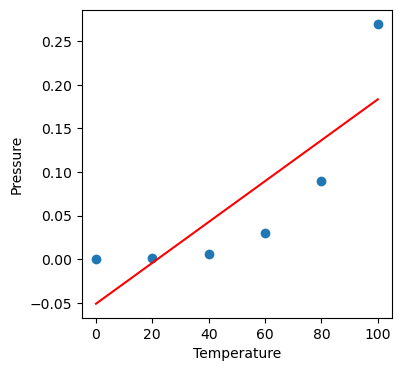

In [15]:
plt.figure(figsize=(4,4))
plt.scatter(X['Temperature'],Y)
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.plot(X,y_pred,color='r')
plt.show()

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
po=PolynomialFeatures(degree=2)
px=po.fit_transform(X)

In [18]:
px

array([[1.0e+00, 0.0e+00, 0.0e+00],
       [1.0e+00, 2.0e+01, 4.0e+02],
       [1.0e+00, 4.0e+01, 1.6e+03],
       [1.0e+00, 6.0e+01, 3.6e+03],
       [1.0e+00, 8.0e+01, 6.4e+03],
       [1.0e+00, 1.0e+02, 1.0e+04]])

In [19]:
lr=LinearRegression()
lr.fit(px,Y)
y_pred_px=lr.predict(px)
print(r2_score(Y,y_pred_px))

0.9568461098911795


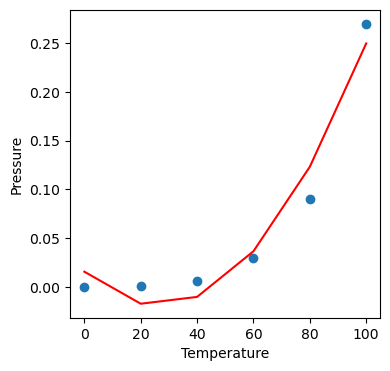

In [20]:
plt.figure(figsize=(4,4))
plt.scatter(X['Temperature'],Y)
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.plot(X,y_pred_px,color='r')
plt.show()